<div class="usecase-title">UC00222: School Enrolment Trend Analysis</div>

<div class="usecase-authors"><b>Authored by: </b>Dennis Jojo Kuriakose, Hans Devu Sunil</div>


<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, data cleaning, visualisation</div>
</div>


<div class="usecase-section-header">Scenario</div>


As education planning analysts, we want to combine Victorian school enrolment data from 2022 to 2025 with school location information so that we can identify where enrolment is growing, where it is declining, and how those patterns differ by sector, school type, year level, region, and local government area.

The main problem is that each yearly CSV has to be cleaned and aligned before trend comparisons can be trusted. The notebook therefore builds a consistent school identifier, keeps schools that are active across the full four-year period, merges location attributes, and then uses tables, charts, heatmaps, and a spatial scatter plot to interpret the final trend dataset.


<div class="usecase-section-header">What this use case will teach you</div>


At the end of this use case you will:
- load enrolment CSV files directly from the project source folder
- clean and combine multi-year school enrolment datasets
- create a stronger school identifier for reliable matching
- merge enrolment data with Victorian school location data
- compare trends by year, sector, school type, region, LGA, and year level
- train and evaluate a baseline predictive model for latest-year enrolment
- produce a cautious one-year-ahead enrolment forecast
- use line charts, bar charts, heatmaps, a workflow diagram, and a location scatter plot to communicate findings


<div class="usecase-section-header">Data sources and scope</div>


This analysis uses the enrolment CSV files from the project source data folder: [UC00206 Source Data](https://github.com/Chameleon-company/MOP-Code/tree/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data).

The notebook uses the 2022, 2023, 2024, and 2025 enrolment files from that folder and joins them to Victorian school location/profile data from the Victorian Government open data API. The main trend comparison focuses on schools that are open and present in all four years, which makes the charts more consistent and avoids comparing schools that enter or leave the dataset partway through the period.

The notebook also includes a baseline modelling section that uses the historical 2022–2025 enrolment patterns to estimate/predict 2026 enrolment values. These 2026 predictions are treated as indicative forecasts, not confirmed future enrolment figures, because they are based only on recent historical trends and available school profile features.

In [1]:
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["legend.frameon"] = False

HTML("""
<style>
.usecase-title, .usecase-duration, .usecase-section-header {
    padding-left: 15px;
    padding-bottom: 10px;
    padding-top: 10px;
    padding-right: 15px;
    background-color: #0f9295;
    color: #fff;
}
.usecase-title {
    font-size: 1.7em;
    font-weight: bold;
}
.usecase-authors, .usecase-level, .usecase-skill {
    padding-left: 15px;
    padding-bottom: 7px;
    padding-top: 7px;
    background-color: #baeaeb;
    font-size: 1.4em;
    color: #121212;
}
.usecase-level-skill  {
    display: flex;
}
.usecase-level, .usecase-skill {
    width: 50%;
}
.usecase-duration, .usecase-skill {
    text-align: right;
    padding-right: 15px;
    padding-bottom: 8px;
    font-size: 1.4em;
}
.usecase-section-header {
    font-weight: bold;
    font-size: 1.9em;
    margin-top: 24px;
    border-radius: 4px;
}
</style>
""")


<div class="usecase-section-header">Project workflow</div>


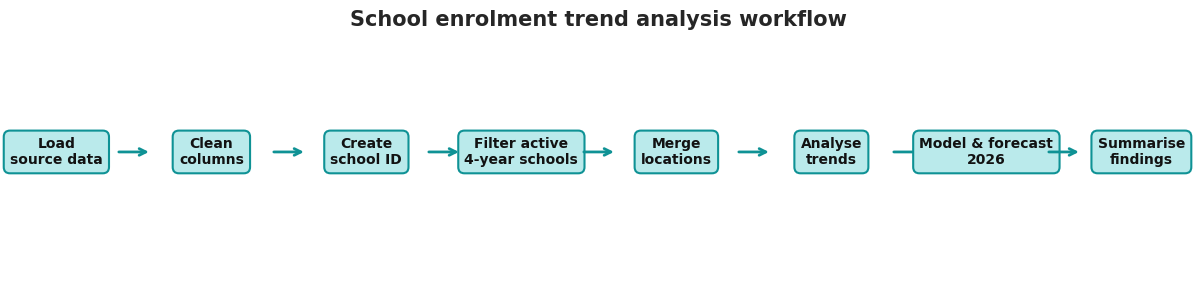

In [2]:
workflow_steps = [
    "Load\nsource data",
    "Clean\ncolumns",
    "Create\nschool ID",
    "Filter active\n4-year schools",
    "Merge\nlocations",
    "Analyse\ntrends",
    "Model & forecast\n2026",
    "Summarise\nfindings",
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

for i, step in enumerate(workflow_steps):
    x = i / (len(workflow_steps) - 1)
    ax.text(
        x,
        0.55,
        step,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#121212",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#baeaeb", edgecolor="#0f9295", linewidth=1.5),
    )
    if i < len(workflow_steps) - 1:
        next_x = (i + 1) / (len(workflow_steps) - 1)
        ax.annotate(
            "",
            xy=(next_x - 0.055, 0.55),
            xytext=(x + 0.055, 0.55),
            xycoords=ax.transAxes,
            textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", color="#0f9295", lw=2),
        )

ax.set_title("School enrolment trend analysis workflow", pad=16)
plt.show()


<div class="usecase-section-header">Load school location data</div>

The first dataset used here contains school location and profile information.  
This includes details such as school name, sector, school type, and regional information, which will later help when comparing enrolment patterns across different groups of schools.


In [3]:
# Import school locations dataset from the Victorian Government open data API.
base_url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"
resource_id = "a70cb615-ed28-48b6-bebe-2d0d346f7927"
url = f"{base_url}?resource_id={resource_id}&limit=5000"

response = requests.get(url, timeout=30)
response.raise_for_status()

data = response.json()
school_locations_df = pd.DataFrame(data["result"]["records"])

print("School location dataset loaded successfully.")
print(school_locations_df.shape)
display(school_locations_df.head())


School location dataset loaded successfully.
(2294, 23)


,_id,Education_Sector,Entity_Type,School_No,School_Name,School_Type,Address_Line_1,Address_Line_2,Address_Town,Address_State,...,Postal_Town,Postal_State,Postal_Postcode,Full_Phone_No,DE_Admin_Region,DE_Admin_AREA,LGA_ID,LGA_Name,X,Y
0,1,Catholic,2,20,Parade College,Secondary,1436 Plenty Road,None,BUNDOORA,VIC,...,BUNDOORA,VIC,3083,03 9468 3300,NORTH-WESTERN VICTORIA,North Eastern Melbourne,66,Banyule (C),145.06,-37.69
1,2,Catholic,2,25,Simonds Catholic College,Secondary,273 Victoria Street,None,WEST MELBOURNE,VIC,...,WEST MELBOURNE,VIC,3003,03 9321 9200,SOUTH-WESTERN VICTORIA,Western Melbourne,460,Melbourne (C),144.95,-37.8
2,3,Catholic,2,26,St Mary’s College Melbourne,Secondary,11 Westbury Street,None,ST KILDA EAST,VIC,...,ST KILDA,VIC,3182,03 9529 6611,SOUTH-EASTERN VICTORIA,Bayside Peninsula,590,Port Phillip (C),144.99,-37.85
3,4,Catholic,2,28,St Patrick's College Ballarat,Secondary,1431 Sturt Street,None,BALLARAT,VIC,...,BALLARAT,VIC,3350,03 5331 1688,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),143.83,-37.55
4,5,Catholic,2,29,St Patrick's School,Primary,119 Drummond Street South,None,BALLARAT,VIC,...,BALLARAT WEST,VIC,3350,03 5332 7680,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),143.84,-37.56


<div class="usecase-section-header">Load enrolment data for multiple years</div>

Since the project is about trends rather than a single-year snapshot, the enrolment files for 2022, 2023, 2024, and 2025 are loaded together.

These files will be combined first and then checked for consistency before further analysis.


In [4]:
# Enrolment datasets for multiple years.
enrolment_source_folder = "https://github.com/Chameleon-company/MOP-Code/tree/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data"

files = {
    "2022": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv335-allschoolsFTEenrolmentsFeb2022.csv",
    "2023": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv355-VIC%20All%20Schools%20Enrolments%202023.csv",
    "2024": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv377_DataVic-AllSchoolsEnrolments-2024.csv",
    "2025": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv403-AllSchoolsEnrolments-2025.csv",
}

print("Enrolment source folder:")
print(enrolment_source_folder)


Enrolment source folder:
https://github.com/Chameleon-company/MOP-Code/tree/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data


In [5]:
def clean_column_names(df):
    """Standardise column names across CSV files and remove encoding artefacts."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
        .str.replace("ï»¿", "", regex=False)
        .str.replace('"', "", regex=False)
        .str.replace(" ", "_")
    )
    return df


dfs = []
source_file_summary = []

for year, file_url in files.items():
    df = pd.read_csv(file_url, encoding="latin1")
    df = clean_column_names(df)

    # Add year label and standardise the school number field.
    df["Census_Year"] = int(year)
    df["School_No"] = df["School_No"].astype(str).str.strip()

    # Convert enrolment totals to numeric values so plots and aggregations work reliably.
    total_columns = [column for column in df.columns if column.endswith("_Total")]
    for column in total_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0)

    source_file_summary.append(
        {
            "Census_Year": int(year),
            "Rows": len(df),
            "Columns": len(df.columns),
            "Total_enrolment": df["Grand_Total"].sum(),
        }
    )
    dfs.append(df)

enrolments_all_df = pd.concat(dfs, ignore_index=True)
source_file_summary_df = pd.DataFrame(source_file_summary)

print("Combined enrolment dataset shape:")
print(enrolments_all_df.shape)
display(source_file_summary_df)
display(enrolments_all_df.head())


Combined enrolment dataset shape:
(9172, 33)


,Census_Year,Rows,Columns,Total_enrolment
0,2022,2286,27,1015530.8
1,2023,2290,27,1032180.0
2,2024,2295,30,1049889.6
3,2025,2301,31,1062900.4


,Education_Sector,Entity_Type,School_No,School_Name,School_Type,School_Status,Prep_Total,Year_1_Total,Year_2_Total,Year_3_Total,...,Grand_Total,Year,CENSUS_TYPE,Census_Year,DE_Admin_Region,LGA_Name,DE_Admin_AREA,Region_Name,AREA_Name,LGA_TYPE
0,Catholic,2,204,St Monica's School,Primary,O,47.0,34.0,58.0,55.0,...,316.0,2022,F,2022,NaN,NaN,NaN,NaN,NaN,NaN
1,Catholic,2,205,St Joseph's School,Primary,O,52.0,55.0,42.0,66.0,...,351.0,2022,F,2022,NaN,NaN,NaN,NaN,NaN,NaN
2,Catholic,2,212,St Brendan's Primary School,Primary,O,1.0,2.0,3.0,3.0,...,15.0,2022,F,2022,NaN,NaN,NaN,NaN,NaN,NaN
3,Catholic,2,219,Sacred Heart College,Secondary,O,0.0,0.0,0.0,0.0,...,1463.0,2022,F,2022,NaN,NaN,NaN,NaN,NaN,NaN
4,Catholic,2,227,St Patrick's School,Primary,O,17.0,23.0,21.0,11.0,...,110.0,2022,F,2022,NaN,NaN,NaN,NaN,NaN,NaN


After combining the annual files, the next step is to make sure that the same kinds of variables are available across all years.

This is important because some yearly files may include slightly different columns or formatting.


<div class="usecase-section-header">Compare column structure across years</div>

Before using the combined enrolment data, we checked which columns are shared across all four yearly files.

Only the overlapping columns are kept so that later comparisons are based on the same set of variables throughout the dataset.


In [6]:
# Find common columns across all year datasets
column_sets = [set(df.columns) for df in dfs]
common_columns = sorted(list(set.intersection(*column_sets)))

print("Number of common columns across all years:", len(common_columns))
print(common_columns)


Number of common columns across all years: 27
['CENSUS_TYPE', 'Census_Year', 'Education_Sector', 'Entity_Type', 'Grand_Total', 'Prep_Total', 'Primary_Total', 'Primary_Ungraded_Total', 'School_Name', 'School_No', 'School_Status', 'School_Type', 'Secondary_Total', 'Secondary_Ungraded_Total', 'Year', 'Year_10_Total', 'Year_11_Total', 'Year_12_Total', 'Year_1_Total', 'Year_2_Total', 'Year_3_Total', 'Year_4_Total', 'Year_5_Total', 'Year_6_Total', 'Year_7_Total', 'Year_8_Total', 'Year_9_Total']


In [7]:
# Keep only common columns
enrolments_all_df = pd.concat([df[common_columns] for df in dfs], ignore_index=True)

print("enrolment dataset after keeping common columns:")
print(enrolments_all_df.shape)
display(enrolments_all_df.head())


enrolment dataset after keeping common columns:
(9172, 27)


,CENSUS_TYPE,Census_Year,Education_Sector,Entity_Type,Grand_Total,Prep_Total,Primary_Total,Primary_Ungraded_Total,School_Name,School_No,...,Year_12_Total,Year_1_Total,Year_2_Total,Year_3_Total,Year_4_Total,Year_5_Total,Year_6_Total,Year_7_Total,Year_8_Total,Year_9_Total
0,F,2022,Catholic,2,316.0,47.0,316.0,0.0,St Monica's School,204,...,0.0,34.0,58.0,55.0,39.0,46.0,37.0,0.0,0.0,0.0
1,F,2022,Catholic,2,351.0,52.0,351.0,0.0,St Joseph's School,205,...,0.0,55.0,42.0,66.0,46.0,46.0,44.0,0.0,0.0,0.0
2,F,2022,Catholic,2,15.0,1.0,15.0,0.0,St Brendan's Primary School,212,...,0.0,2.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0
3,F,2022,Catholic,2,1463.0,0.0,0.0,0.0,Sacred Heart College,219,...,243.0,0.0,0.0,0.0,0.0,0.0,0.0,237.0,239.0,260.0
4,F,2022,Catholic,2,110.0,17.0,110.0,0.0,St Patrick's School,227,...,0.0,23.0,21.0,11.0,14.0,10.0,14.0,0.0,0.0,0.0


Keeping only the shared columns makes the combined dataset more stable and avoids problems caused by differences between annual file formats.


<div class="usecase-section-header">Check whether school numbers are unique enough</div>

At this point, we wanted to confirm whether `School_No` could be used safely as a matching key.

A quick check shows that some school numbers appear more than once in the same year, which means they cannot always be treated as unique by themselves.


In [8]:
# Check counts by year
for year in sorted(enrolments_all_df["Census_Year"].unique()):
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    print(
        f"Year {year}: Total rows = {len(df_year)}, "
        f"Unique School_No = {df_year['School_No'].nunique()}"
    )


Year 2022: Total rows = 2286, Unique School_No = 2145
Year 2023: Total rows = 2290, Unique School_No = 2149
Year 2024: Total rows = 2295, Unique School_No = 2155
Year 2025: Total rows = 2301, Unique School_No = 2162


In [9]:
# Show duplicate School_No examples
for year in sorted(enrolments_all_df["Census_Year"].unique()):
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    duplicates = df_year[df_year.duplicated(subset=["School_No"], keep=False)]

    if not duplicates.empty:
        example_school = duplicates["School_No"].iloc[0]
        print(f"\nYear {year} - Example duplicate School_No: {example_school}")
        display(duplicates[duplicates["School_No"] == example_school].head())



Year 2022 - Example duplicate School_No: 250


,CENSUS_TYPE,Census_Year,Education_Sector,Entity_Type,Grand_Total,Prep_Total,Primary_Total,Primary_Ungraded_Total,School_Name,School_No,...,Year_12_Total,Year_1_Total,Year_2_Total,Year_3_Total,Year_4_Total,Year_5_Total,Year_6_Total,Year_7_Total,Year_8_Total,Year_9_Total
6,F,2022,Catholic,2,1209.0,0.0,0.0,0.0,Star of the Sea College,250,...,194.0,0.0,0.0,0.0,0.0,0.0,0.0,203.0,206.0,198.0
492,F,2022,Government,1,332.0,63.0,332.0,0.0,Flemington Primary School,250,...,0.0,60.0,61.0,36.0,55.0,26.0,31.0,0.0,0.0,0.0



Year 2023 - Example duplicate School_No: 26


,CENSUS_TYPE,Census_Year,Education_Sector,Entity_Type,Grand_Total,Prep_Total,Primary_Total,Primary_Ungraded_Total,School_Name,School_No,...,Year_12_Total,Year_1_Total,Year_2_Total,Year_3_Total,Year_4_Total,Year_5_Total,Year_6_Total,Year_7_Total,Year_8_Total,Year_9_Total
2288,F,2023,Catholic,2,515.0,0.0,0.0,0.0,St Marys College Melbourne,26,...,94.0,0.0,0.0,0.0,0.0,0.0,0.0,73.0,95.0,72.0
2790,F,2023,Government,1,278.0,42.0,278.0,0.0,Belmont Primary School,26,...,0.0,30.0,38.0,50.0,36.0,40.0,42.0,0.0,0.0,0.0



Year 2024 - Example duplicate School_No: 26


,CENSUS_TYPE,Census_Year,Education_Sector,Entity_Type,Grand_Total,Prep_Total,Primary_Total,Primary_Ungraded_Total,School_Name,School_No,...,Year_12_Total,Year_1_Total,Year_2_Total,Year_3_Total,Year_4_Total,Year_5_Total,Year_6_Total,Year_7_Total,Year_8_Total,Year_9_Total
4578,F,2024,Catholic,2,474.0,0.0,0.0,0.0,St Marys College Melbourne,26,...,100.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0,71.0,85.0
5076,F,2024,Government,1,293.0,37.0,293.0,0.0,Belmont Primary School,26,...,0.0,47.0,29.0,44.0,53.0,40.0,43.0,0.0,0.0,0.0



Year 2025 - Example duplicate School_No: 1527


,CENSUS_TYPE,Census_Year,Education_Sector,Entity_Type,Grand_Total,Prep_Total,Primary_Total,Primary_Ungraded_Total,School_Name,School_No,...,Year_12_Total,Year_1_Total,Year_2_Total,Year_3_Total,Year_4_Total,Year_5_Total,Year_6_Total,Year_7_Total,Year_8_Total,Year_9_Total
6871,F,2025,Catholic,2,161.4,24.0,161.4,0.0,St Margaret Mary's School,1527,...,0.0,26.0,32.4,15.0,33.0,11.0,20.0,0.0,0.0,0.0
7386,F,2025,Government,1,15.0,3.0,15.0,0.0,Dookie Primary School,1527,...,0.0,1.0,2.0,1.0,1.0,5.0,2.0,0.0,0.0,0.0


Because of these repeated school numbers, merging on `School_No` alone would be risky.

To reduce that problem, a stronger identifier is needed before filtering and merging the datasets.


<div class="usecase-section-header">Build a stronger school identifier</div>

To make matching more reliable, a new identifier is created using both `Entity_Type` and `School_No`.

This gives a more consistent school key across the multi-year enrolment files and the location dataset.


In [10]:
def create_unique_id(row):
    """Build a stable school key using entity type and school number."""
    entity_type = int(row["Entity_Type"])
    school_no = int(float(row["School_No"]))

    if entity_type == 1:
        return 100000 + school_no
    if entity_type == 2:
        return 200000 + school_no
    return school_no


enrolments_all_df["Unique_School_ID"] = enrolments_all_df.apply(create_unique_id, axis=1)

display(enrolments_all_df[["School_No", "Entity_Type", "Unique_School_ID"]].head(10))


,School_No,Entity_Type,Unique_School_ID
0,204,2,200204
1,205,2,200205
2,212,2,200212
3,219,2,200219
4,227,2,200227
5,236,2,200236
6,250,2,200250
7,251,2,200251
8,252,2,200252
9,262,2,200262


This extra identifier is mainly used to avoid incorrect matches when the same school number appears under different categories.


<div class="usecase-section-header">Narrow the dataset for more consistent comparison</div>

For the trend part of the project, we only want schools that can be followed properly across the full period.

So instead of using every row exactly as it appears, we reduce the dataset to schools that have a consistent presence across all four years. That makes later comparisons more meaningful.


In [11]:
# Review school status counts
status_counts = (
    enrolments_all_df.groupby(["Census_Year", "School_Status"])["Unique_School_ID"]
    .nunique()
    .reset_index(name="School_Count")
)

display(status_counts)


,Census_Year,School_Status,School_Count
0,2022,C,1
1,2022,O,2284
2,2022,U,1
3,2023,C,1
4,2023,O,2286
5,2023,U,3
6,2024,O,2294
7,2024,U,1
8,2025,C,4
9,2025,O,2297


In [12]:
# Limit the dataset to schools that are active in the comparison period
active_schools_df = enrolments_all_df[enrolments_all_df["School_Status"] == "O"].copy()

# Count number of years each school appears
school_year_counts = (
    active_schools_df.groupby("Unique_School_ID")["Census_Year"]
    .nunique()
    .reset_index(name="Year_Count")
)

schools_all_years = school_year_counts[school_year_counts["Year_Count"] == 4]["Unique_School_ID"]

consistent_schools_df = active_schools_df[
    active_schools_df["Unique_School_ID"].isin(schools_all_years)
].copy()

print("Schools included across all four years:")
print(consistent_schools_df.groupby("Census_Year")["Unique_School_ID"].nunique())


Schools included across all four years:
Census_Year
2022    2246
2023    2246
2024    2246
2025    2246
Name: Unique_School_ID, dtype: int64


This step is useful because it removes part of the noise that would come from schools appearing in only some years of the dataset.


<div class="usecase-section-header">Prepare the location dataset for matching</div>

Before merging the two datasets, the same school identifier needs to exist in the location data as well.

That way, the merge is based on the same key on both sides instead of relying on school number alone.


In [13]:
school_locations_df = clean_column_names(school_locations_df)
school_locations_df["School_No"] = school_locations_df["School_No"].astype(str).str.strip()
school_locations_df["Entity_Type"] = pd.to_numeric(school_locations_df["Entity_Type"], errors="coerce").astype(int)

for coordinate_column in ["X", "Y"]:
    school_locations_df[coordinate_column] = pd.to_numeric(school_locations_df[coordinate_column], errors="coerce")

school_locations_df["Unique_School_ID"] = school_locations_df.apply(create_unique_id, axis=1)

print("School location dataset with unique ID:")
display(school_locations_df[["School_No", "Entity_Type", "Unique_School_ID", "DE_Admin_Region", "LGA_Name", "X", "Y"]].head(10))


School location dataset with unique ID:


,School_No,Entity_Type,Unique_School_ID,DE_Admin_Region,LGA_Name,X,Y
0,20,2,200020,NORTH-WESTERN VICTORIA,Banyule (C),145.06,-37.69
1,25,2,200025,SOUTH-WESTERN VICTORIA,Melbourne (C),144.95,-37.80
2,26,2,200026,SOUTH-EASTERN VICTORIA,Port Phillip (C),144.99,-37.85
3,28,2,200028,SOUTH-WESTERN VICTORIA,Ballarat (C),143.83,-37.55
4,29,2,200029,SOUTH-WESTERN VICTORIA,Ballarat (C),143.84,-37.56
5,30,2,200030,SOUTH-WESTERN VICTORIA,Ballarat (C),143.87,-37.56
6,33,2,200033,SOUTH-WESTERN VICTORIA,Warrnambool (C),142.47,-38.37
7,35,2,200035,SOUTH-WESTERN VICTORIA,Ballarat (C),143.82,-37.55
8,60,2,200060,NORTH-EASTERN VICTORIA,Mansfield (S),146.08,-37.05
9,77,2,200077,SOUTH-WESTERN VICTORIA,Hobsons Bay (C),144.88,-37.84


<div class="usecase-section-header">Merge enrolment and location information</div>

Once the enrolment data and location data use the same identifier, they can be joined into one dataset.

This gives a table that includes both historical enrolment values and school profile information in the same place.


In [14]:
final_df = pd.merge(
    consistent_schools_df,
    school_locations_df,
    on="Unique_School_ID",
    how="left",
    suffixes=("_enrol", "_loc"),
)

# Recreate clean, reader-friendly profile columns after the merge.
for column in ["Education_Sector", "Entity_Type", "School_No", "School_Name", "School_Type"]:
    enrol_column = f"{column}_enrol"
    loc_column = f"{column}_loc"
    if enrol_column in final_df.columns and loc_column in final_df.columns:
        final_df[column] = final_df[enrol_column].combine_first(final_df[loc_column])
    elif enrol_column in final_df.columns:
        final_df[column] = final_df[enrol_column]
    elif loc_column in final_df.columns:
        final_df[column] = final_df[loc_column]

print("Final merged dataset shape:")
print(final_df.shape)

preview_columns = [
    "Census_Year",
    "Unique_School_ID",
    "School_Name",
    "Education_Sector",
    "School_Type",
    "DE_Admin_Region",
    "LGA_Name",
    "Grand_Total",
]
display(final_df[preview_columns].head())


Final merged dataset shape:
(8984, 56)


,Census_Year,Unique_School_ID,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,Grand_Total
0,2022,200204,St Monica's School,Catholic,Primary,NORTH-WESTERN VICTORIA,Greater Bendigo (C),316.0
1,2022,200205,St Joseph's School,Catholic,Primary,NORTH-EASTERN VICTORIA,Benalla (RC),351.0
2,2022,200219,Sacred Heart College,Catholic,Secondary,SOUTH-WESTERN VICTORIA,Greater Geelong (C),1463.0
3,2022,200227,St Patrick's School,Catholic,Primary,SOUTH-WESTERN VICTORIA,Northern Grampians (S),110.0
4,2022,200236,St Joseph's College Mildura,Catholic,Secondary,NORTH-WESTERN VICTORIA,Mildura (RC),800.0


The merged dataset is the main working dataset for the next stage of the project.


<div class="usecase-section-header">Run a few checks on the merged dataset</div>

Before moving into deeper analysis, we checked the merged dataset for basic issues such as missing values, year coverage, and the number of unique schools included.

This is mainly to confirm that the merge works as expected.


In [15]:
print("Missing values in final dataset:")
display(final_df.isnull().sum().sort_values(ascending=False).head(15))


Missing values in final dataset:


,0
Address_Line_2,8944
Postal_Address_Line_2,8928
Y,4
X,4
CENSUS_TYPE,0
Census_Year,0
Education_Sector_enrol,0
Entity_Type_enrol,0
School_Name_enrol,0
School_No_enrol,0


In [16]:
years_included = [int(year) for year in sorted(final_df["Census_Year"].unique())]

print("Unique schools in final dataset:", final_df["Unique_School_ID"].nunique())
print("Years included:", years_included)
print("Education sectors:", sorted(final_df["Education_Sector"].dropna().unique()))
print("School types:", sorted(final_df["School_Type"].dropna().unique()))
print("Regions:", sorted(final_df["DE_Admin_Region"].dropna().unique()))


Unique schools in final dataset: 2246
Years included: [2022, 2023, 2024, 2025]
Education sectors: ['Catholic', 'Government', 'Independent']
School types: ['Language', 'Pri/Sec', 'Primary', 'Secondary', 'Special']
Regions: ['NORTH-EASTERN VICTORIA', 'NORTH-WESTERN VICTORIA', 'SOUTH-EASTERN VICTORIA', 'SOUTH-WESTERN VICTORIA']


<div class="usecase-section-header">Prepare metrics for analysis</div>


In [17]:
grade_columns = [
    "Prep_Total",
    "Year_1_Total",
    "Year_2_Total",
    "Year_3_Total",
    "Year_4_Total",
    "Year_5_Total",
    "Year_6_Total",
    "Year_7_Total",
    "Year_8_Total",
    "Year_9_Total",
    "Year_10_Total",
    "Year_11_Total",
    "Year_12_Total",
]

grade_labels = [
    "Prep",
    "Year 1",
    "Year 2",
    "Year 3",
    "Year 4",
    "Year 5",
    "Year 6",
    "Year 7",
    "Year 8",
    "Year 9",
    "Year 10",
    "Year 11",
    "Year 12",
]

year_columns = sorted(final_df["Census_Year"].unique())
start_year = year_columns[0]
end_year = year_columns[-1]

final_df["Primary_Share"] = np.where(final_df["Grand_Total"] > 0, final_df["Primary_Total"] / final_df["Grand_Total"], np.nan)
final_df["Secondary_Share"] = np.where(final_df["Grand_Total"] > 0, final_df["Secondary_Total"] / final_df["Grand_Total"], np.nan)

year_summary = (
    final_df.groupby("Census_Year")
    .agg(
        Schools=("Unique_School_ID", "nunique"),
        Total_enrolment=("Grand_Total", "sum"),
        Average_enrolment=("Grand_Total", "mean"),
        Primary_Total=("Primary_Total", "sum"),
        Secondary_Total=("Secondary_Total", "sum"),
    )
    .reset_index()
)
year_summary["Year_on_Year_Change"] = year_summary["Total_enrolment"].diff()
year_summary["Change_from_Start"] = year_summary["Total_enrolment"] - year_summary.loc[0, "Total_enrolment"]
year_summary["Pct_Change_from_Start"] = year_summary["Change_from_Start"] / year_summary.loc[0, "Total_enrolment"] * 100

school_profile = (
    final_df.sort_values("Census_Year")
    .groupby("Unique_School_ID")
    .agg(
        School_Name=("School_Name", "first"),
        Education_Sector=("Education_Sector", "first"),
        School_Type=("School_Type", "first"),
        DE_Admin_Region=("DE_Admin_Region", "first"),
        DE_Admin_AREA=("DE_Admin_AREA", "first"),
        LGA_Name=("LGA_Name", "first"),
        X=("X", "first"),
        Y=("Y", "first"),
    )
    .reset_index()
)

school_year_totals = (
    final_df.pivot_table(index="Unique_School_ID", columns="Census_Year", values="Grand_Total", aggfunc="sum")
    .reset_index()
)

school_trend_df = school_profile.merge(school_year_totals, on="Unique_School_ID", how="left")
school_trend_df["Change_2022_2025"] = school_trend_df[end_year] - school_trend_df[start_year]
school_trend_df["Pct_Change_2022_2025"] = np.where(
    school_trend_df[start_year] > 0,
    school_trend_df["Change_2022_2025"] / school_trend_df[start_year] * 100,
    np.nan,
)

formatters = {
    "Total_enrolment": "{:,.0f}",
    "Average_enrolment": "{:,.1f}",
    "Primary_Total": "{:,.0f}",
    "Secondary_Total": "{:,.0f}",
    "Year_on_Year_Change": "{:,.0f}",
    "Change_from_Start": "{:,.0f}",
    "Pct_Change_from_Start": "{:.2f}%",
}


def display_formatted_table(df, format_map=None, na_rep="-"):
    """Display a readable table without relying on pandas Styler/Jinja."""
    formatted_df = df.copy()
    for column, formatter in (format_map or {}).items():
        if column in formatted_df.columns:
            formatted_df[column] = formatted_df[column].apply(
                lambda value: na_rep if pd.isna(value) else formatter.format(value)
            )
    display(formatted_df)


display_formatted_table(year_summary, formatters)


,Census_Year,Schools,Total_enrolment,Average_enrolment,Primary_Total,Secondary_Total,Year_on_Year_Change,Change_from_Start,Pct_Change_from_Start
0,2022,2246,"1,010,183",449.8,"560,230","449,953",-,0,0.00%
1,2023,2246,"1,027,743",457.6,"566,598","461,146","17,560","17,560",1.74%
2,2024,2246,"1,040,390",463.2,"569,254","471,135","12,646","30,207",2.99%
3,2025,2246,"1,047,072",466.2,"566,084","480,988","6,682","36,889",3.65%


<div class="usecase-section-header">Overall enrolment trend</div>


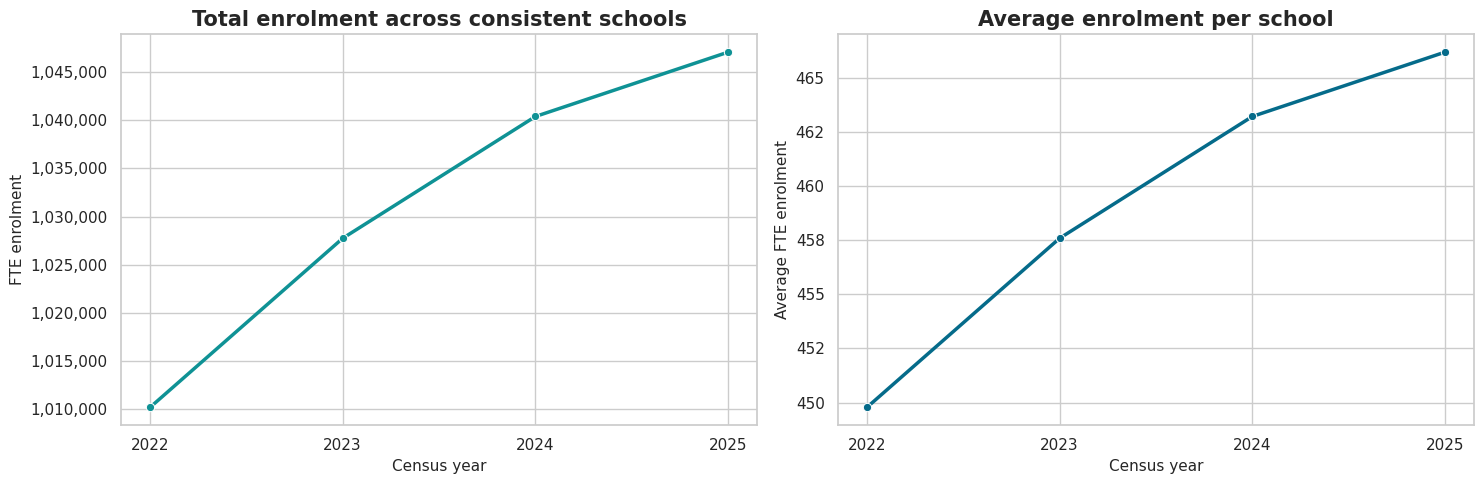

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=year_summary,
    x="Census_Year",
    y="Total_enrolment",
    marker="o",
    linewidth=2.5,
    color="#0f9295",
    ax=axes[0],
)
axes[0].set_title("Total enrolment across consistent schools")
axes[0].set_xlabel("Census year")
axes[0].set_ylabel("FTE enrolment")
axes[0].set_xticks(year_columns)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

sns.lineplot(
    data=year_summary,
    x="Census_Year",
    y="Average_enrolment",
    marker="o",
    linewidth=2.5,
    color="#056b8a",
    ax=axes[1],
)
axes[1].set_title("Average enrolment per school")
axes[1].set_xlabel("Census year")
axes[1].set_ylabel("Average FTE enrolment")
axes[1].set_xticks(year_columns)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

plt.tight_layout()
plt.show()


<div class="usecase-section-header">Sector and school type trends</div>


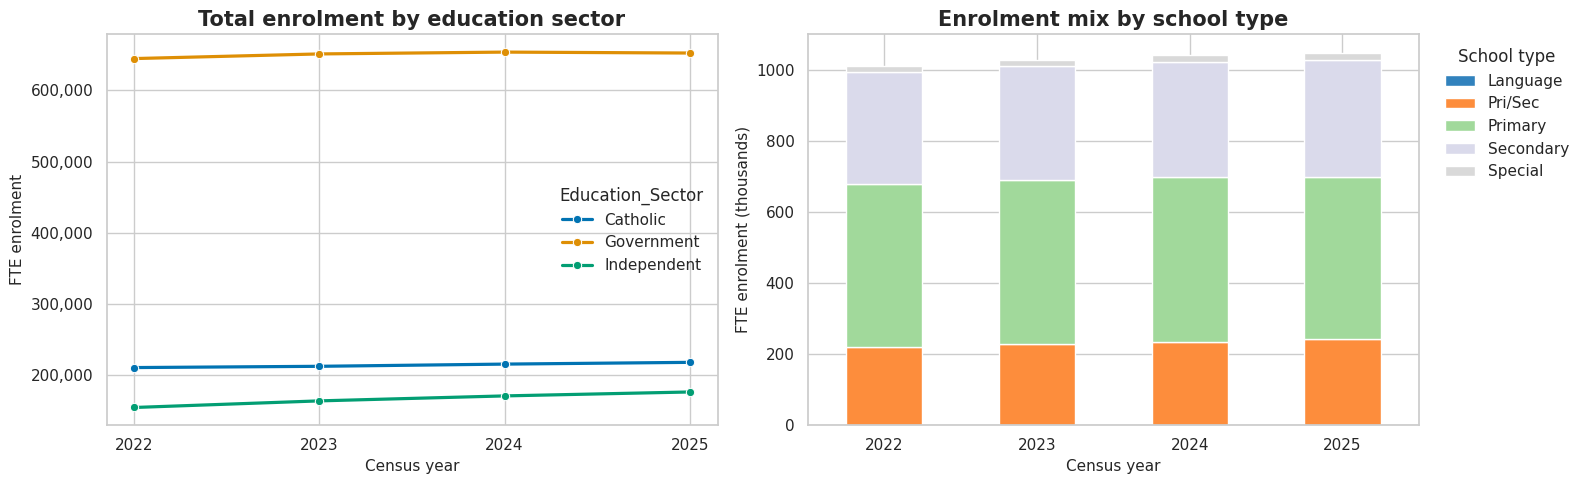

,Education_Sector,Census_Year,Schools,Total_enrolment,Average_enrolment
0,Catholic,2022,488,"210,718",431.8
1,Catholic,2023,488,"212,484",435.4
2,Catholic,2024,488,"215,580",441.8
3,Catholic,2025,488,"218,038",446.8
4,Government,2022,1538,"644,828",419.3
5,Government,2023,1538,"651,344",423.5
6,Government,2024,1538,"653,913",425.2
7,Government,2025,1538,"652,610",424.3
8,Independent,2022,220,"154,636",702.9
9,Independent,2023,220,"163,914",745.1


In [19]:
sector_year = (
    final_df.groupby(["Education_Sector", "Census_Year"])
    .agg(
        Schools=("Unique_School_ID", "nunique"),
        Total_enrolment=("Grand_Total", "sum"),
        Average_enrolment=("Grand_Total", "mean"),
    )
    .reset_index()
)

school_type_year = (
    final_df.groupby(["School_Type", "Census_Year"])
    .agg(Total_enrolment=("Grand_Total", "sum"), Schools=("Unique_School_ID", "nunique"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=sector_year,
    x="Census_Year",
    y="Total_enrolment",
    hue="Education_Sector",
    marker="o",
    linewidth=2.3,
    ax=axes[0],
)
axes[0].set_title("Total enrolment by education sector")
axes[0].set_xlabel("Census year")
axes[0].set_ylabel("FTE enrolment")
axes[0].set_xticks(year_columns)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

school_type_pivot = school_type_year.pivot(index="Census_Year", columns="School_Type", values="Total_enrolment") / 1000
school_type_pivot.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20c")
axes[1].set_title("Enrolment mix by school type")
axes[1].set_xlabel("Census year")
axes[1].set_ylabel("FTE enrolment (thousands)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="School type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

display_formatted_table(sector_year.sort_values(["Education_Sector", "Census_Year"]), {
    "Total_enrolment": "{:,.0f}",
    "Average_enrolment": "{:,.1f}",
})


<div class="usecase-section-header">Year level heatmap</div>


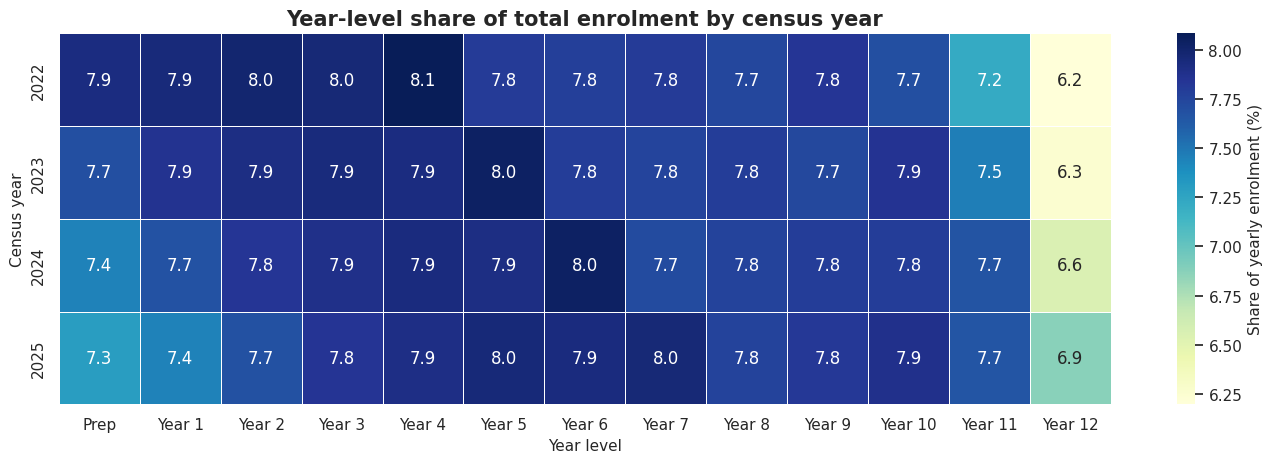

,Change_2022_2025,Pct_Change_2022_2025
Year 12,"9,191",14.9%
Year 11,"7,148",9.9%
Year 10,"4,716",6.1%
Year 7,"4,421",5.7%
Year 6,"4,378",5.6%
Year 5,"4,296",5.5%
Year 8,"2,998",3.9%
Year 9,"2,664",3.4%
Year 3,"1,673",2.1%
Year 4,"1,074",1.3%


In [20]:
grade_totals = final_df.groupby("Census_Year")[grade_columns].sum()
grade_totals.columns = grade_labels
grade_share = grade_totals.div(grade_totals.sum(axis=1), axis=0) * 100

grade_change = (grade_totals.loc[end_year] - grade_totals.loc[start_year]).to_frame("Change_2022_2025")
grade_change["Pct_Change_2022_2025"] = grade_change["Change_2022_2025"] / grade_totals.loc[start_year] * 100

fig, ax = plt.subplots(figsize=(14, 4.8))
sns.heatmap(
    grade_share,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Share of yearly enrolment (%)"},
    ax=ax,
)
ax.set_title("Year-level share of total enrolment by census year")
ax.set_xlabel("Year level")
ax.set_ylabel("Census year")
plt.tight_layout()
plt.show()

display_formatted_table(grade_change.sort_values("Change_2022_2025", ascending=False), {
    "Change_2022_2025": "{:,.0f}",
    "Pct_Change_2022_2025": "{:.1f}%",
})


<div class="usecase-section-header">Regional heatmap and growth areas</div>


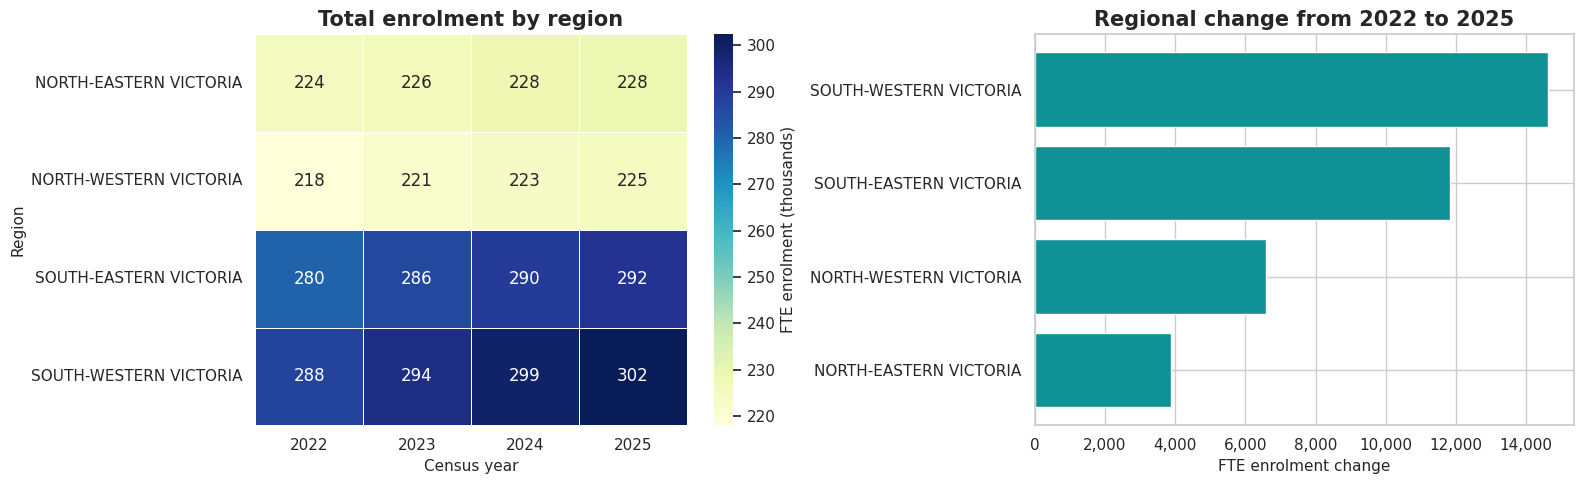

Census_Year,2022,2023,2024,2025,Change_2022_2025,Pct_Change_2022_2025
DE_Admin_Region,,,,,,
SOUTH-WESTERN VICTORIA,"287,776","294,342","299,262","302,403","14,627",5.1%
SOUTH-EASTERN VICTORIA,"280,081","286,244","289,739","291,898","11,817",4.2%
NORTH-WESTERN VICTORIA,"217,970","221,318","223,313","224,543","6,573",3.0%
NORTH-EASTERN VICTORIA,"224,357","225,839","228,076","228,228","3,872",1.7%


In [21]:
region_year = (
    final_df.groupby(["DE_Admin_Region", "Census_Year"])
    .agg(
        Schools=("Unique_School_ID", "nunique"),
        Total_enrolment=("Grand_Total", "sum"),
        Average_enrolment=("Grand_Total", "mean"),
    )
    .reset_index()
)

region_pivot = region_year.pivot(index="DE_Admin_Region", columns="Census_Year", values="Total_enrolment")
region_change = region_pivot.copy()
region_change["Change_2022_2025"] = region_change[end_year] - region_change[start_year]
region_change["Pct_Change_2022_2025"] = region_change["Change_2022_2025"] / region_change[start_year] * 100
region_change = region_change.sort_values("Change_2022_2025", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    region_pivot / 1000,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "FTE enrolment (thousands)"},
    ax=axes[0],
)
axes[0].set_title("Total enrolment by region")
axes[0].set_xlabel("Census year")
axes[0].set_ylabel("Region")

region_plot = region_change.sort_values("Change_2022_2025")
axes[1].barh(region_plot.index, region_plot["Change_2022_2025"], color="#0f9295")
axes[1].set_title(f"Regional change from {start_year} to {end_year}")
axes[1].set_xlabel("FTE enrolment change")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

plt.tight_layout()
plt.show()

region_formatters = {year: "{:,.0f}" for year in year_columns}
region_formatters.update({
    "Change_2022_2025": "{:,.0f}",
    "Pct_Change_2022_2025": "{:.1f}%",
})
display_formatted_table(region_change, region_formatters)


<div class="usecase-section-header">LGA and school-level change</div>


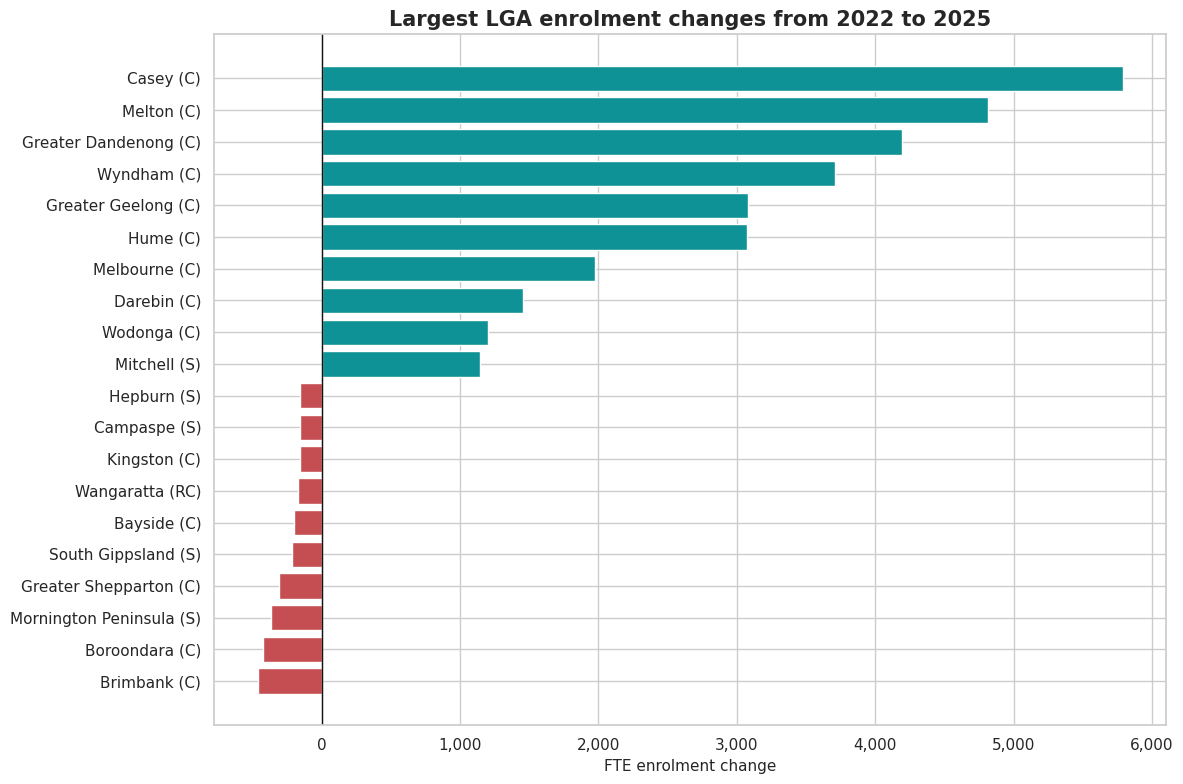

Top 10 school increases


,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,2022,2025,Change_2022_2025,Pct_Change_2022_2025
1730,Haileybury College,Independent,Pri/Sec,SOUTH-EASTERN VICTORIA,Greater Dandenong (C),"2,467","4,895","2,428",98.4%
1289,Cranbourne West Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Casey (C),461,"1,597","1,136",246.3%
2157,Hume Anglican Grammar,Independent,Pri/Sec,NORTH-WESTERN VICTORIA,Hume (C),"1,957","2,943",986,50.4%
2143,Indie School Wodonga,Independent,Special,NORTH-EASTERN VICTORIA,Wodonga (C),628,"1,559",931,148.2%
1242,Clyde Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Casey (C),138,"1,069",931,674.6%
2181,St Joseph's Flexible Learning Centre Melbourne,Catholic,Special,SOUTH-WESTERN VICTORIA,Melbourne (C),459,"1,367",908,197.8%
2229,Iona College Geelong,Catholic,Secondary,SOUTH-WESTERN VICTORIA,Greater Geelong (C),559,"1,356",797,142.6%
1375,Saltwater P-9 College,Government,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"1,447","2,164",717,49.6%
1236,Virtual School Victoria,Government,Pri/Sec,NORTH-WESTERN VICTORIA,Darebin (C),"2,211","2,926",715,32.4%
1241,Elevation Secondary College,Government,Secondary,NORTH-WESTERN VICTORIA,Hume (C),486,"1,176",690,142.0%


Top 10 school decreases


,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,2022,2025,Change_2022_2025,Pct_Change_2022_2025
1174,Hazel Glen College,Government,Pri/Sec,NORTH-WESTERN VICTORIA,Whittlesea (C),"2,805","2,163",-642,-22.9%
1452,Mornington Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Mornington Peninsula (S),"1,396",817,-579,-41.5%
1980,St Francis Xavier College,Catholic,Secondary,SOUTH-EASTERN VICTORIA,Cardinia (S),"3,303","2,829",-474,-14.4%
1142,Epping Views Primary School,Government,Primary,NORTH-WESTERN VICTORIA,Whittlesea (C),"1,089",682,-407,-37.4%
1238,Mount Erin Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Frankston (C),825,492,-333,-40.3%
1121,Carranballac P-9 College,Government,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"1,186",863,-323,-27.2%
1360,Parkdale Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Kingston (C),"1,715","1,418",-297,-17.3%
1535,Tarneit P-9 College,Government,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"2,278","1,987",-291,-12.8%
515,Torquay P-6 College,Government,Primary,SOUTH-WESTERN VICTORIA,Surf Coast (S),898,613,-285,-31.7%
1303,Bendigo South East 7-10 Secondary College,Government,Secondary,NORTH-WESTERN VICTORIA,Greater Bendigo (C),"1,322","1,041",-281,-21.2%


In [22]:
lga_pivot = final_df.pivot_table(index="LGA_Name", columns="Census_Year", values="Grand_Total", aggfunc="sum")
lga_change = lga_pivot.dropna(subset=[start_year, end_year]).copy()
lga_change["Change_2022_2025"] = lga_change[end_year] - lga_change[start_year]
lga_change["Pct_Change_2022_2025"] = lga_change["Change_2022_2025"] / lga_change[start_year] * 100

top_lga_growth = lga_change.sort_values("Change_2022_2025", ascending=False).head(10)
top_lga_decline = lga_change.sort_values("Change_2022_2025").head(10)
lga_plot = pd.concat([top_lga_decline, top_lga_growth]).sort_values("Change_2022_2025")

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = np.where(lga_plot["Change_2022_2025"] >= 0, "#0f9295", "#c44e52")
ax.barh(lga_plot.index, lga_plot["Change_2022_2025"], color=bar_colors)
ax.axvline(0, color="#121212", linewidth=1)
ax.set_title(f"Largest LGA enrolment changes from {start_year} to {end_year}")
ax.set_xlabel("FTE enrolment change")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
plt.tight_layout()
plt.show()

top_school_growth = school_trend_df.sort_values("Change_2022_2025", ascending=False).head(10)
top_school_decline = school_trend_df.sort_values("Change_2022_2025").head(10)

school_display_columns = [
    "School_Name",
    "Education_Sector",
    "School_Type",
    "DE_Admin_Region",
    "LGA_Name",
    start_year,
    end_year,
    "Change_2022_2025",
    "Pct_Change_2022_2025",
]

print("Top 10 school increases")
display_formatted_table(top_school_growth[school_display_columns], {
    start_year: "{:,.0f}",
    end_year: "{:,.0f}",
    "Change_2022_2025": "{:,.0f}",
    "Pct_Change_2022_2025": "{:.1f}%",
})

print("Top 10 school decreases")
display_formatted_table(top_school_decline[school_display_columns], {
    start_year: "{:,.0f}",
    end_year: "{:,.0f}",
    "Change_2022_2025": "{:,.0f}",
    "Pct_Change_2022_2025": "{:.1f}%",
})


<div class="usecase-section-header">Distribution and spatial pattern of school change</div>


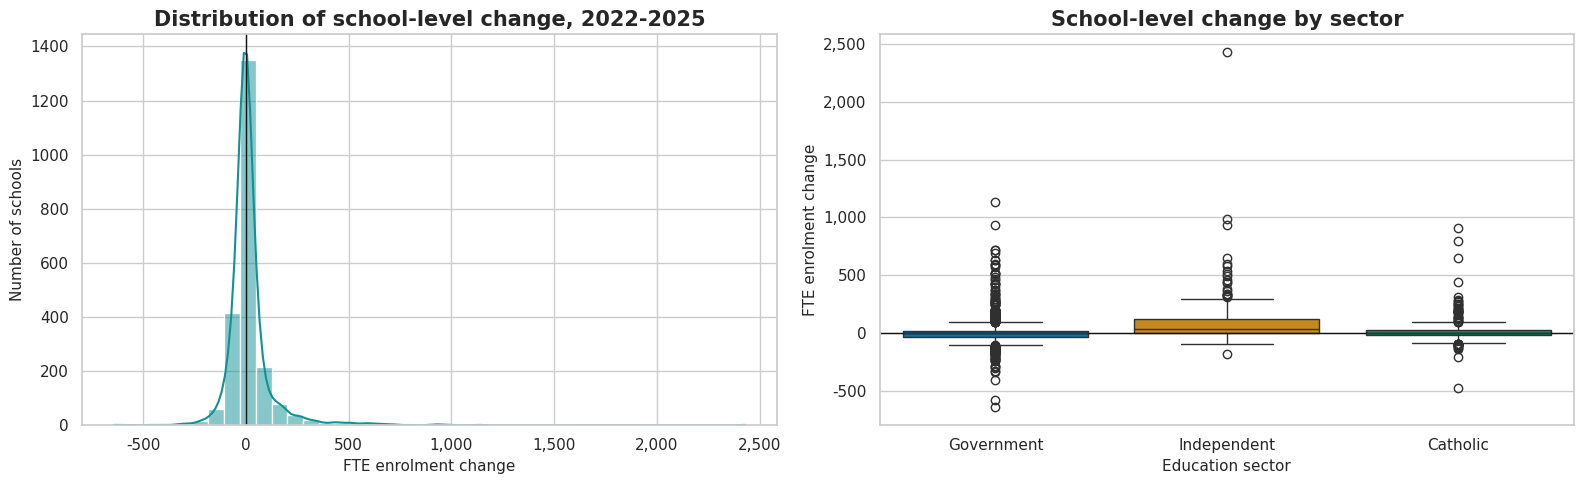

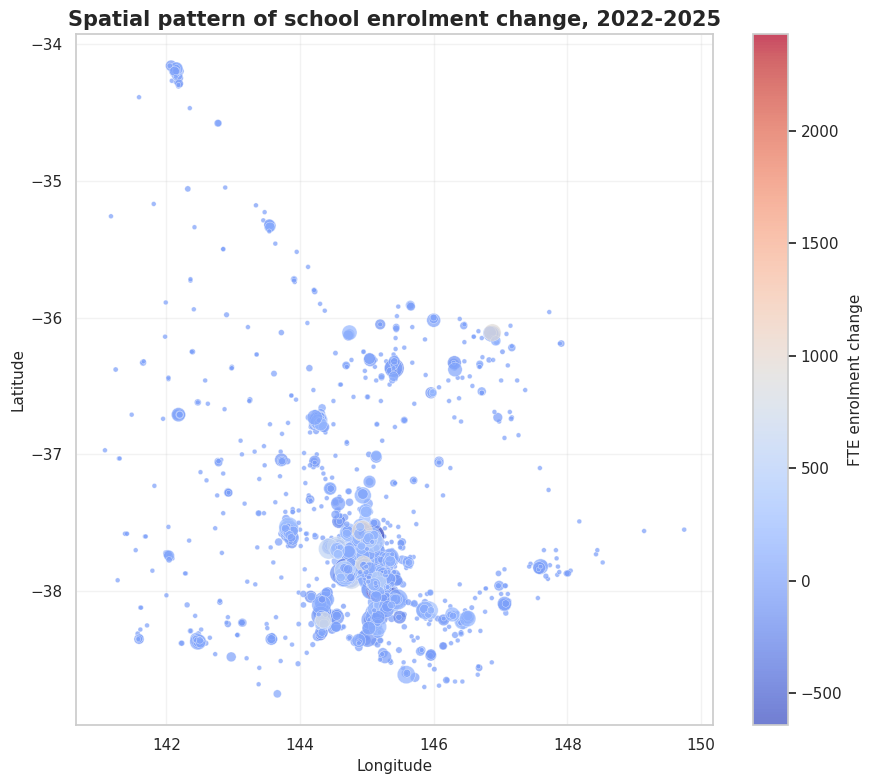

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=school_trend_df,
    x="Change_2022_2025",
    bins=40,
    kde=True,
    color="#0f9295",
    ax=axes[0],
)
axes[0].axvline(0, color="#121212", linewidth=1)
axes[0].set_title(f"Distribution of school-level change, {start_year}-{end_year}")
axes[0].set_xlabel("FTE enrolment change")
axes[0].set_ylabel("Number of schools")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

sns.boxplot(
    data=school_trend_df,
    x="Education_Sector",
    y="Change_2022_2025",
    hue="Education_Sector",
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(0, color="#121212", linewidth=1)
axes[1].set_title("School-level change by sector")
axes[1].set_xlabel("Education sector")
axes[1].set_ylabel("FTE enrolment change")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

plt.tight_layout()
plt.show()

map_df = school_trend_df.dropna(subset=["X", "Y", "Change_2022_2025", end_year]).copy()
marker_sizes = np.clip(map_df[end_year] / 10, 12, 220)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    map_df["X"],
    map_df["Y"],
    c=map_df["Change_2022_2025"],
    s=marker_sizes,
    cmap="coolwarm",
    alpha=0.72,
    edgecolors="white",
    linewidths=0.3,
)
ax.set_title(f"Spatial pattern of school enrolment change, {start_year}-{end_year}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.25)
colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("FTE enrolment change")
plt.tight_layout()
plt.show()


<div class="usecase-section-header">Correlation heatmap</div>


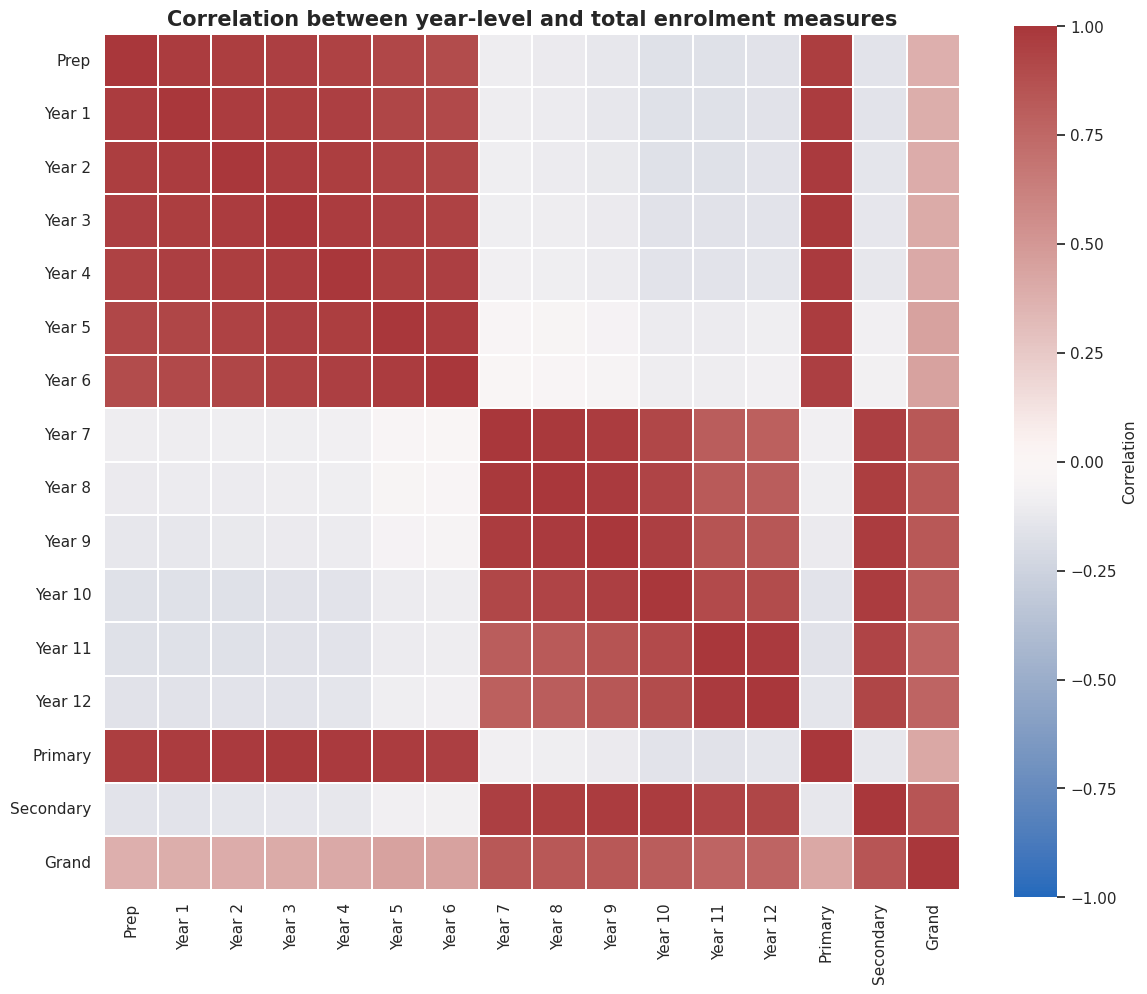

In [24]:
correlation_columns = grade_columns + ["Primary_Total", "Secondary_Total", "Grand_Total"]
correlation_matrix = final_df[correlation_columns].corr()
correlation_matrix.index = [label.replace("_", " ").replace(" Total", "") for label in correlation_matrix.index]
correlation_matrix.columns = [label.replace("_", " ").replace(" Total", "") for label in correlation_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation between year-level and total enrolment measures")
plt.tight_layout()
plt.show()


<div class="usecase-section-header">Predictive modelling and 2026 forecast</div>

This section adds a simple supervised learning model so the notebook includes both descriptive analysis and predictive modelling. The model uses each school's previous enrolment, previous enrolment change, year index, education sector, school type, and region to predict the latest available enrolment.

Because the dataset only has four annual snapshots, this should be treated as a baseline forecasting model rather than a high-certainty long-term planning tool. It is still useful because it creates a measurable prediction task, compares the model against a simple previous-year baseline, and produces a cautious 2026 forecast.


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Prepare a school-year panel dataset for supervised modelling.
model_base_columns = [
    "Unique_School_ID",
    "Census_Year",
    "Grand_Total",
    "School_Name",
    "Education_Sector",
    "School_Type",
    "DE_Admin_Region",
    "LGA_Name",
]

model_base_df = final_df[model_base_columns].copy()
model_base_df["Grand_Total"] = pd.to_numeric(model_base_df["Grand_Total"], errors="coerce")
model_base_df["Census_Year"] = pd.to_numeric(model_base_df["Census_Year"], errors="coerce").astype("Int64")

panel_model_df = (
    model_base_df
    .dropna(subset=["Unique_School_ID", "Census_Year", "Grand_Total"])
    .sort_values(["Unique_School_ID", "Census_Year"])
    .copy()
)

panel_model_df["Previous_Year_enrolment"] = (
    panel_model_df.groupby("Unique_School_ID")["Grand_Total"].shift(1)
)
panel_model_df["enrolment_Change"] = (
    panel_model_df.groupby("Unique_School_ID")["Grand_Total"].diff()
)
panel_model_df["Previous_Year_Change"] = (
    panel_model_df.groupby("Unique_School_ID")["enrolment_Change"].shift(1)
)
panel_model_df["Previous_Year_Change"] = panel_model_df["Previous_Year_Change"].fillna(0)
panel_model_df["Year_Index"] = panel_model_df["Census_Year"].astype(int) - int(start_year)

model_ready_df = panel_model_df.dropna(subset=["Previous_Year_enrolment"]).copy()

categorical_features = ["Education_Sector", "School_Type", "DE_Admin_Region"]
numeric_features = ["Year_Index", "Previous_Year_enrolment", "Previous_Year_Change"]
feature_columns = numeric_features + categorical_features

for column in categorical_features:
    model_ready_df[column] = model_ready_df[column].fillna("Unknown").astype(str)

train_df = model_ready_df[model_ready_df["Census_Year"].astype(int) < int(end_year)].copy()
test_df = model_ready_df[model_ready_df["Census_Year"].astype(int) == int(end_year)].copy()

print(f"Training rows used for the model: {len(train_df):,}")
print(f"Testing rows used for latest-year validation: {len(test_df):,}")
print("Feature columns:", feature_columns)

display(model_ready_df.head())


Training rows used for the model: 4,492
Testing rows used for latest-year validation: 2,246
Feature columns: ['Year_Index', 'Previous_Year_enrolment', 'Previous_Year_Change', 'Education_Sector', 'School_Type', 'DE_Admin_Region']


,Unique_School_ID,Census_Year,Grand_Total,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,Previous_Year_enrolment,enrolment_Change,Previous_Year_Change,Year_Index
2734,100001,2023,84.8,Alberton Primary School,Government,Primary,SOUTH-EASTERN VICTORIA,Wellington (S),75.2,9.6,0.0,1
4980,100001,2024,88.0,Alberton Primary School,Government,Primary,SOUTH-EASTERN VICTORIA,Wellington (S),84.8,3.2,9.6,2
6995,100001,2025,97.2,Alberton Primary School,Government,Primary,SOUTH-EASTERN VICTORIA,Wellington (S),88.0,9.2,3.2,3
2735,100003,2023,178.8,Allansford and District Primary School,Government,Primary,SOUTH-WESTERN VICTORIA,Warrnambool (C),174.0,4.8,0.0,1
4981,100003,2024,178.0,Allansford and District Primary School,Government,Primary,SOUTH-WESTERN VICTORIA,Warrnambool (C),178.8,-0.8,4.8,2


In [26]:
# Build a reproducible modelling pipeline.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numeric", "passthrough", numeric_features),
    ],
    remainder="drop",
)

enrolment_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", Ridge(alpha=1.0)),
    ]
)

X_train = train_df[feature_columns]
y_train = train_df["Grand_Total"]
X_test = test_df[feature_columns]
y_test = test_df["Grand_Total"]

enrolment_model.fit(X_train, y_train)

test_predictions = np.clip(enrolment_model.predict(X_test), 0, None)

model_test_results = test_df.copy()
model_test_results["Predicted_enrolment"] = test_predictions
model_test_results["Baseline_Prediction"] = model_test_results["Previous_Year_enrolment"]
model_test_results["Prediction_Error"] = model_test_results["Predicted_enrolment"] - model_test_results["Grand_Total"]
model_test_results["Absolute_Error"] = model_test_results["Prediction_Error"].abs()


def evaluate_predictions(actual, predicted, model_name):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    non_zero_mask = actual != 0
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "MAPE_percent": np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])) * 100,
    }


model_metrics = pd.DataFrame([
    evaluate_predictions(y_test, model_test_results["Baseline_Prediction"], "Previous-year baseline"),
    evaluate_predictions(y_test, model_test_results["Predicted_enrolment"], "Ridge regression model"),
])

print(f"Model validation target year: {int(end_year)}")
display_formatted_table(model_metrics, {
    "MAE": "{:,.1f}",
    "RMSE": "{:,.1f}",
    "R2": "{:.3f}",
    "MAPE_percent": "{:.1f}%",
})

model_result_columns = [
    "Unique_School_ID",
    "School_Name",
    "Education_Sector",
    "School_Type",
    "DE_Admin_Region",
    "Grand_Total",
    "Previous_Year_enrolment",
    "Predicted_enrolment",
    "Prediction_Error",
    "Absolute_Error",
]

print("Largest model errors in the validation year")
display_formatted_table(
    model_test_results[model_result_columns].sort_values("Absolute_Error", ascending=False).head(10),
    {
        "Grand_Total": "{:,.1f}",
        "Previous_Year_enrolment": "{:,.1f}",
        "Predicted_enrolment": "{:,.1f}",
        "Prediction_Error": "{:,.1f}",
        "Absolute_Error": "{:,.1f}",
    },
)


Model validation target year: 2025


,Model,MAE,RMSE,R2,MAPE_percent
0,Previous-year baseline,22.2,42.1,0.993,7.2%
1,Ridge regression model,19.5,33.1,0.996,9.6%


Largest model errors in the validation year


,Unique_School_ID,School_Name,Education_Sector,School_Type,DE_Admin_Region,Grand_Total,Previous_Year_enrolment,Predicted_enrolment,Prediction_Error,Absolute_Error
6970,202079,Saints College,Catholic,Special,SOUTH-WESTERN VICTORIA,"1,367.0",836.0,923.7,-443.3,443.3
8231,106261,Virtual School Victoria,Government,Pri/Sec,NORTH-WESTERN VICTORIA,"2,926.4","2,525.6","2,541.4",-385.0,385.0
8237,107086,Clyde Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,"1,069.0",676.0,774.6,-294.4,294.4
8284,107748,Cranbourne West Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,"1,596.6","1,180.4","1,306.6",-290.0,290.0
6870,201766,St Francis Xavier College,Catholic,Secondary,SOUTH-EASTERN VICTORIA,"2,828.6","3,098.6","3,056.9",228.3,228.3
8649,201906,Al-Taqwa College,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,"2,570.0","2,298.6","2,354.7",-215.3,215.3
8496,108868,Hallam Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,713.6,505.0,512.1,-201.5,201.5
6989,202231,Iona College Geelong,Catholic,Secondary,SOUTH-WESTERN VICTORIA,"1,356.2","1,074.7","1,162.3",-193.9,193.9
8169,105552,Hazel Glen College,Government,Pri/Sec,NORTH-WESTERN VICTORIA,"2,162.7","2,396.7","2,345.5",182.8,182.8
8652,201919,Bacchus Marsh Grammar,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,"3,837.0","3,555.0","3,657.9",-179.1,179.1


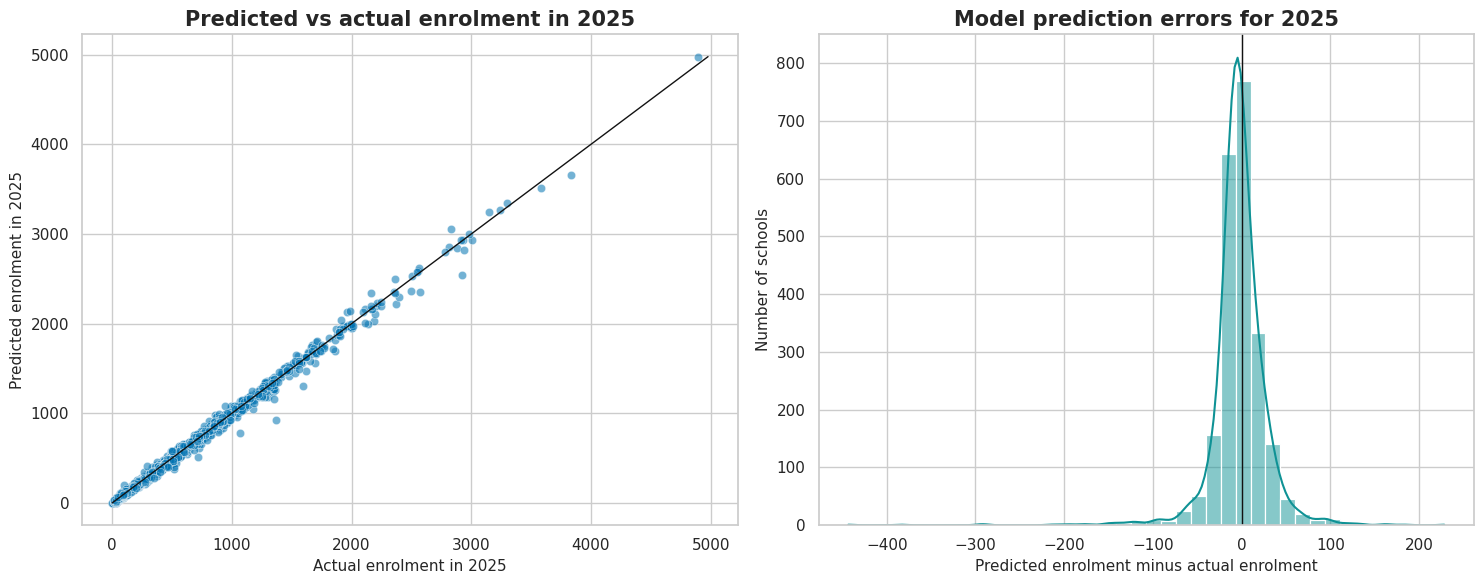

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=model_test_results,
    x="Grand_Total",
    y="Predicted_enrolment",
    alpha=0.55,
    ax=axes[0],
)
min_value = min(model_test_results["Grand_Total"].min(), model_test_results["Predicted_enrolment"].min())
max_value = max(model_test_results["Grand_Total"].max(), model_test_results["Predicted_enrolment"].max())
axes[0].plot([min_value, max_value], [min_value, max_value], color="#121212", linewidth=1)
axes[0].set_title(f"Predicted vs actual enrolment in {int(end_year)}")
axes[0].set_xlabel(f"Actual enrolment in {int(end_year)}")
axes[0].set_ylabel(f"Predicted enrolment in {int(end_year)}")

sns.histplot(model_test_results["Prediction_Error"], bins=40, kde=True, color="#0f9295", ax=axes[1])
axes[1].axvline(0, color="#121212", linewidth=1)
axes[1].set_title(f"Model prediction errors for {int(end_year)}")
axes[1].set_xlabel("Predicted enrolment minus actual enrolment")
axes[1].set_ylabel("Number of schools")

plt.tight_layout()
plt.show()


Top 10 forecast increases


,Unique_School_ID,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,Previous_Year_enrolment,Previous_Year_Change,Forecast_Year,Forecast_enrolment,Forecast_Change_from_2025
6970,202079,Saints College,Catholic,Special,SOUTH-WESTERN VICTORIA,Melbourne (C),"1,367.0",531.0,2026,"1,538.3",171.3
8231,106261,Virtual School Victoria,Government,Pri/Sec,NORTH-WESTERN VICTORIA,Darebin (C),"2,926.4",400.8,2026,"3,068.5",142.1
8652,201919,Bacchus Marsh Grammar,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,Moorabool (S),"3,837.0",282.0,2026,"3,975.3",138.3
8284,107748,Cranbourne West Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Casey (C),"1,596.6",416.2,2026,"1,731.1",134.5
8699,202052,Hume Anglican Grammar,Independent,Pri/Sec,NORTH-WESTERN VICTORIA,Hume (C),"2,943.0",285.0,2026,"3,071.0",128.0
8649,201906,Al-Taqwa College,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"2,570.0",271.4,2026,"2,693.5",123.5
8237,107086,Clyde Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Casey (C),"1,069.0",393.0,2026,"1,191.6",122.6
8668,201957,Good News Lutheran College,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"1,844.0",230.0,2026,"1,948.1",104.1
6894,201811,St Francis Catholic College,Catholic,Secondary,SOUTH-WESTERN VICTORIA,Melton (C),"1,864.0",296.0,2026,"1,967.8",103.8
8608,201775,Westbourne Grammar School,Independent,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"2,136.0",216.0,2026,"2,238.4",102.4


Top 10 forecast decreases


,Unique_School_ID,School_Name,Education_Sector,School_Type,DE_Admin_Region,LGA_Name,Previous_Year_enrolment,Previous_Year_Change,Forecast_Year,Forecast_enrolment,Forecast_Change_from_2025
6870,201766,St Francis Xavier College,Catholic,Secondary,SOUTH-EASTERN VICTORIA,Cardinia (S),"2,828.6",-270.0,2026,"2,763.8",-64.8
8169,105552,Hazel Glen College,Government,Pri/Sec,NORTH-WESTERN VICTORIA,Whittlesea (C),"2,162.7",-234.0,2026,"2,101.0",-61.7
8127,105501,Truganina P-9 College,Government,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"1,960.0",-211.0,2026,"1,906.8",-53.2
8137,105513,Epping Views Primary School,Government,Primary,NORTH-WESTERN VICTORIA,Whittlesea (C),682.0,-122.0,2026,634.8,-47.2
8530,108914,Tarneit P-9 College,Government,Pri/Sec,SOUTH-WESTERN VICTORIA,Wyndham (C),"1,987.0",-183.2,2026,"1,942.6",-44.4
8233,107028,Mount Erin Secondary College,Government,Secondary,SOUTH-EASTERN VICTORIA,Frankston (C),492.4,-127.8,2026,448.2,-44.2
8484,108854,Tarneit Senior College,Government,Secondary,SOUTH-WESTERN VICTORIA,Wyndham (C),941.0,-142.2,2026,898.2,-42.8
8416,108724,Forest Hill College,Government,Secondary,NORTH-EASTERN VICTORIA,Whitehorse (C),373.0,-108.0,2026,330.8,-42.2
8277,107680,Camberwell High School,Government,Secondary,NORTH-EASTERN VICTORIA,Boroondara (C),807.1,-111.7,2026,767.7,-39.4
8126,105500,Harvest Home Primary School,Government,Primary,NORTH-WESTERN VICTORIA,Whittlesea (C),876.4,-102.2,2026,837.1,-39.3


Sector-level 2026 forecast


,Education_Sector,enrolment_2025,Forecast_enrolment_2026,Forecast_Change_2025_to_2026,School_Count
0,Catholic,"218,038","215,309","-2,730",488
1,Government,"652,610","638,055","-14,555",1538
2,Independent,"176,424","182,420","5,996",220


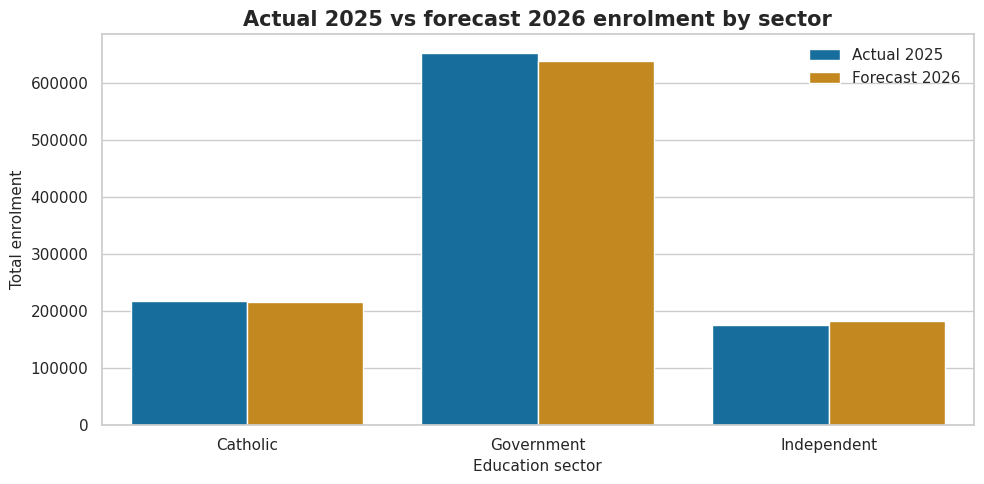

In [28]:
# Produce a cautious one-year-ahead forecast for 2026.
forecast_year = int(end_year) + 1

latest_school_rows = panel_model_df[panel_model_df["Census_Year"].astype(int).eq(int(end_year))].copy()
latest_school_rows["Census_Year"] = forecast_year
latest_school_rows["Year_Index"] = forecast_year - int(start_year)
latest_school_rows["Previous_Year_enrolment"] = latest_school_rows["Grand_Total"]
latest_school_rows["Previous_Year_Change"] = latest_school_rows["enrolment_Change"].fillna(0)

for column in categorical_features:
    latest_school_rows[column] = latest_school_rows[column].fillna("Unknown").astype(str)

forecast_predictions = np.clip(enrolment_model.predict(latest_school_rows[feature_columns]), 0, None)

school_forecast_2026 = latest_school_rows[[
    "Unique_School_ID",
    "School_Name",
    "Education_Sector",
    "School_Type",
    "DE_Admin_Region",
    "LGA_Name",
    "Previous_Year_enrolment",
    "Previous_Year_Change",
]].copy()

school_forecast_2026["Forecast_Year"] = forecast_year
school_forecast_2026["Forecast_enrolment"] = forecast_predictions
school_forecast_2026["Forecast_Change_from_2025"] = (
    school_forecast_2026["Forecast_enrolment"] - school_forecast_2026["Previous_Year_enrolment"]
)

forecast_summary_by_sector = (
    school_forecast_2026.groupby("Education_Sector")
    .agg(
        enrolment_2025=("Previous_Year_enrolment", "sum"),
        Forecast_enrolment_2026=("Forecast_enrolment", "sum"),
        Forecast_Change_2025_to_2026=("Forecast_Change_from_2025", "sum"),
        School_Count=("Unique_School_ID", "nunique"),
    )
    .reset_index()
)

print("Top 10 forecast increases")
display_formatted_table(
    school_forecast_2026.sort_values("Forecast_Change_from_2025", ascending=False).head(10),
    {
        "Previous_Year_enrolment": "{:,.1f}",
        "Previous_Year_Change": "{:,.1f}",
        "Forecast_enrolment": "{:,.1f}",
        "Forecast_Change_from_2025": "{:,.1f}",
    },
)

print("Top 10 forecast decreases")
display_formatted_table(
    school_forecast_2026.sort_values("Forecast_Change_from_2025").head(10),
    {
        "Previous_Year_enrolment": "{:,.1f}",
        "Previous_Year_Change": "{:,.1f}",
        "Forecast_enrolment": "{:,.1f}",
        "Forecast_Change_from_2025": "{:,.1f}",
    },
)

print("Sector-level 2026 forecast")
display_formatted_table(forecast_summary_by_sector, {
    "enrolment_2025": "{:,.0f}",
    "Forecast_enrolment_2026": "{:,.0f}",
    "Forecast_Change_2025_to_2026": "{:,.0f}",
})

forecast_sector_long = forecast_summary_by_sector.melt(
    id_vars="Education_Sector",
    value_vars=["enrolment_2025", "Forecast_enrolment_2026"],
    var_name="Year_Type",
    value_name="Total_enrolment",
)
forecast_sector_long["Year_Type"] = forecast_sector_long["Year_Type"].replace({
    "enrolment_2025": "Actual 2025",
    "Forecast_enrolment_2026": "Forecast 2026",
})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=forecast_sector_long,
    x="Education_Sector",
    y="Total_enrolment",
    hue="Year_Type",
)
plt.title("Actual 2025 vs forecast 2026 enrolment by sector")
plt.xlabel("Education sector")
plt.ylabel("Total enrolment")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="")
plt.tight_layout()
plt.show()


<div class="usecase-section-header">Key findings</div>


In [29]:
overall_start = year_summary.loc[year_summary["Census_Year"] == start_year, "Total_enrolment"].iloc[0]
overall_end = year_summary.loc[year_summary["Census_Year"] == end_year, "Total_enrolment"].iloc[0]
overall_change = overall_end - overall_start
overall_pct_change = overall_change / overall_start * 100

sector_pivot = sector_year.pivot(index="Education_Sector", columns="Census_Year", values="Total_enrolment")
sector_change = sector_pivot.copy()
sector_change["Change_2022_2025"] = sector_change[end_year] - sector_change[start_year]
sector_change["Pct_Change_2022_2025"] = sector_change["Change_2022_2025"] / sector_change[start_year] * 100
largest_sector = sector_change.sort_values("Change_2022_2025", ascending=False).index[0]
fastest_sector = sector_change.sort_values("Pct_Change_2022_2025", ascending=False).index[0]

top_region = region_change.sort_values("Change_2022_2025", ascending=False).index[0]
top_lga = lga_change.sort_values("Change_2022_2025", ascending=False).index[0]
top_school = school_trend_df.sort_values("Change_2022_2025", ascending=False).iloc[0]
most_declining_school = school_trend_df.sort_values("Change_2022_2025").iloc[0]

ridge_metrics = model_metrics.loc[model_metrics["Model"].eq("Ridge regression model")].iloc[0]
baseline_metrics = model_metrics.loc[model_metrics["Model"].eq("Previous-year baseline")].iloc[0]
forecast_total = school_forecast_2026["Forecast_enrolment"].sum()
forecast_change = school_forecast_2026["Forecast_Change_from_2025"].sum()

summary_findings = pd.DataFrame(
    {
        "Finding": [
            "Overall enrolment change",
            "Largest sector growth by enrolment count",
            "Fastest sector growth by percentage",
            "Largest regional growth",
            "Largest LGA growth",
            "Largest school increase",
            "Largest school decrease",
            "Model validation performance",
            "Forecast 2026 total enrolment",
        ],
        "Result": [
            f"{overall_change:,.0f} FTE students ({overall_pct_change:.1f}%) from {start_year} to {end_year}",
            largest_sector,
            fastest_sector,
            top_region,
            top_lga,
            f"{top_school['School_Name']} ({top_school['Change_2022_2025']:,.0f} FTE)",
            f"{most_declining_school['School_Name']} ({most_declining_school['Change_2022_2025']:,.0f} FTE)",
            f"Ridge MAE {ridge_metrics['MAE']:,.1f}, compared with baseline MAE {baseline_metrics['MAE']:,.1f}",
            f"{forecast_total:,.0f} FTE students ({forecast_change:+,.0f} from 2025)",
        ],
    }
)

display(summary_findings)

print(
    f"Across the {school_trend_df.shape[0]:,} schools that were open and present in every year, "
    f"total enrolment increased by {overall_change:,.0f} FTE students from {start_year} to {end_year}. "
    f"The baseline Ridge model forecasts {forecast_total:,.0f} FTE students for {forecast_year}."
)


,Finding,Result
0,Overall enrolment change,"36,889 FTE students (3.7%) from 2022 to 2025"
1,Largest sector growth by enrolment count,Independent
2,Fastest sector growth by percentage,Independent
3,Largest regional growth,SOUTH-WESTERN VICTORIA
4,Largest LGA growth,Casey (C)
5,Largest school increase,"Haileybury College (2,428 FTE)"
6,Largest school decrease,Hazel Glen College (-642 FTE)
7,Model validation performance,"Ridge MAE 19.5, compared with baseline MAE 22.2"
8,Forecast 2026 total enrolment,"1,035,783 FTE students (-11,289 from 2025)"


Across the 2,246 schools that were open and present in every year, total enrolment increased by 36,889 FTE students from 2022 to 2025. The baseline Ridge model forecasts 1,035,783 FTE students for 2026.


<div class="usecase-section-header">Conclusion, limitations, and references</div>

The final dataset shows a clear way to compare enrolment trends because each school is tracked with the same identifier across the full 2022-2025 period. The strongest parts of the analysis are the yearly trend views, the sector and school-type breakdowns, the year-level heatmap, the regional/LGA comparisons, and the baseline predictive model, because together they show both the scale, location, and likely short-term direction of enrolment change.

Important limitations:
- The notebook uses FTE enrolment totals, so values may not equal a simple headcount of individual students.
- The trend comparison is restricted to schools that were open and present in all four years, which improves consistency but excludes new, closed, or missing schools.
- Location attributes come from the school location API at run time, so small changes in the source API could slightly change the merged profile fields.
- The spatial scatter plot uses longitude and latitude points without a base map, so it is best read as a geographic pattern check rather than a precise mapping product.
- The predictive model is a baseline model trained on only four yearly snapshots, so the 2026 forecast should be treated as an indicative estimate rather than a formal enrolment projection.

References:
- Enrolment CSV files: [Chameleon-company/MOP-Code UC00206 Source Data](https://github.com/Chameleon-company/MOP-Code/tree/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data)
- School location/profile data: Victorian Government open data API accessed through https://discover.data.vic.gov.au/dataset/school-locations-2024
